In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
from scipy import signal
import importlib
import joblib

In [2]:
import functions
importlib.reload(functions)

<module 'functions' from 'c:\\Users\\vacha\\OneDrive\\Desktop\\Programming\\Python\\Synapse\\functions.py'>

In [11]:
data = np.load("./data/window_cache.npz", allow_pickle=True)

raw  = data["windows_raw"]
norm = data["windows_norm"]
y = data["y"]
meta = data["meta"].tolist()
groups = data["groups"]

In [33]:
#To create the data 
#50% overlap because tree models benefit from it
functions.createData(102, 51)

In [35]:
xTime = functions.timeFeatures(norm)
np.save("./data/xtime.npy", xTime)

In [36]:
xFreq = functions.freqFeatures(raw)
np.save("./data/xfreq.npy", xFreq)

In [37]:
xInter = functions.interChannelFeatures(norm)
np.save("./data/xinter.npy", xInter)  

In [38]:
xHjorth = functions.hjorthFeatures(norm)
np.save("./data/xhjorth.npy", xHjorth)

In [25]:
df_meta = pd.DataFrame(meta)
df_meta["idx"] = np.arange(len(meta))

temporal_rows = []

for (sub, sess, trial), g in df_meta.groupby(["subject", "session", "trial"]):
    idxs = g["idx"].values
    windows_norm_trial = norm[idxs]

    slope, volatility, delta = functions.temporalFeatures(windows_norm_trial)

    temporal_rows.append({
        "subject": sub,
        "session": sess,
        "trial": trial,
        "rms_slope": slope,
        "rms_volatility": volatility,
        "rms_delta": delta
    })

df_temporal = pd.DataFrame(temporal_rows)

df_full = df_meta.merge(df_temporal,on=["subject", "session", "trial"],how="left")

xTemporal = df_full[["rms_slope", "rms_volatility", "rms_delta"]].values.astype(np.float32)
np.save("./data/xtemp.npy", xTemporal)

In [3]:
xTime = np.load("./data/xtime.npy")
xFreq = np.load("./data/xfreq.npy")
xInter = np.load("./data/xinter.npy")
xHjorth = np.load("./data/xhjorth.npy")
xTemporal = np.load("./data/xtemp.npy")

In [26]:
x = np.hstack([xTime, xFreq, xInter, xHjorth, xTemporal])

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import f1_score, confusion_matrix

In [ ]:
models = {
#    "LogisticRegression": {
#       "pipeline": Pipeline([
#            ("scaler", StandardScaler()),
#            ("clf", LogisticRegression(max_iter=500))
#        ]),
#        "param_grid": {
#            "scaler": [StandardScaler(), RobustScaler()],
#            "clf__C": [0.01, 0.1, 1, 10]
#        }
#    },

    "KNN": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "param_grid": {
            "scaler": [StandardScaler(), RobustScaler(), MinMaxScaler()],
            "clf__n_neighbors": [3, 5, 7, 11],
            "clf__weights": ["uniform", "distance"]
        }
    },

    "RandomForest": {
        "pipeline": RandomForestClassifier(),
        "param_grid": {
            "n_estimators": [200, 400],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5]
        }
    },

#   "GradientBoosting": {
#        "pipeline": GradientBoostingClassifier(),
 #       "param_grid": {
  #          "n_estimators": [100, 200],
   #         "learning_rate": [0.05, 0.1],
   #         "max_depth": [3, 5]
   #     }
   # },

    "LinearSVM": {
        "pipeline": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(dual=False, max_iter=5000))
         ]),
        "param_grid": {
        "scaler": [StandardScaler(), RobustScaler()],
        "clf__C": [0.01, 0.1, 1, 10, 100]
    }
},

#    "SVM": {
#        "pipeline": Pipeline([
#            ("scaler", StandardScaler()),
#            ("clf", SVC())
#        ]),
#        "param_grid": {
#            "scaler": [StandardScaler(), RobustScaler(), MinMaxScaler()],
#            "clf__C": [0.1, 1, 10, 100],
#            "clf__gamma": ["scale", 0.01, 0.1],
#            "clf__kernel": ["rbf"]
#        }
#    },
}

In [ ]:
#DO NOT RUN
results = {}

for name, cfg in models.items():
    print("\n==============================")
    print(f"Training model: {name}")
    print("==============================")

    grid = GridSearchCV(
        estimator=cfg["pipeline"],
        param_grid=cfg["param_grid"],
        cv=gkf,
        scoring="f1_macro",
        n_jobs=-1,     
        verbose=2
    )

    grid.fit(x, y, groups=groups)

    results[name] = {
        "best_score": grid.best_score_,
        "best_params": grid.best_params_,
        "best_estimator": grid.best_estimator_
    }

    print(f"Best Macro F1: {grid.best_score_:.4f}")
    print(f"Best Params: {grid.best_params_}")



Training model: KNN
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Macro F1: 0.4260
Best Params: {'clf__n_neighbors': 11, 'clf__weights': 'distance', 'scaler': RobustScaler()}

Training model: RandomForest
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Macro F1: 0.4750
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 400}

Training model: GradientBoosting
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Macro F1: 0.4872
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Training model: LinearSVM
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Macro F1: 0.4189
Best Params: {'clf__C': 10, 'scaler': RobustScaler()}


Shifted to HistGradientBoostingClassifier for speed upgrade

In [27]:
groups = [m["subject"] for m in meta]
gkf = GroupKFold(n_splits = 5)
np.savez("features.npz", x=x, y=y, groups = groups)

In [28]:
y_true_trials = []
y_pred_trials = []

for train_idx, test_idx in gkf.split(x, y, groups):
    X_train, X_test = x[train_idx], x[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    meta_test = [meta[i] for i in test_idx]

    model = HistGradientBoostingClassifier(
        max_depth=5,
        max_iter=200,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    df = pd.DataFrame({
        "subject": [m["subject"] for m in meta_test],
        "session": [m["session"] for m in meta_test],
        "trial":   [m["trial"] for m in meta_test],
        "gesture": y_test,
        "y_pred":  y_pred
    })

    trial_df = (
        df.groupby(["subject", "session", "trial", "gesture"])
        .agg(
              y_true=("gesture", "first"),
              y_pred=("y_pred", functions.soft_vote)
        )
        .reset_index()
    )

    y_true_trials.extend(trial_df["y_true"].values)
    y_pred_trials.extend(trial_df["y_pred"].values)


In [29]:
macrof1 = f1_score(y_true_trials, y_pred_trials, average="macro")
print("Trial-level Macro F1:", macrof1)

Trial-level Macro F1: 0.7105680860544215


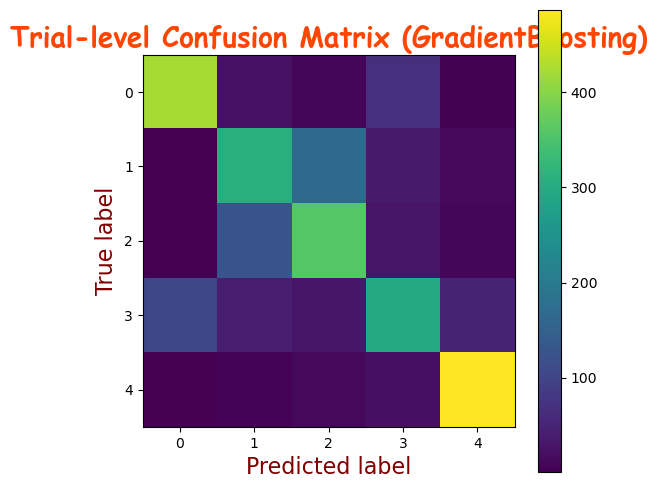

In [30]:
cm = confusion_matrix(y_true_trials, y_pred_trials)
plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation="nearest")
plt.colorbar()
plt.xlabel("Predicted label", fontdict = functions.normalFont)
plt.ylabel("True label", fontdict = functions.normalFont)
plt.title("Trial-level Confusion Matrix (GradientBoosting)", fontdict = functions.titleFont)
plt.show()

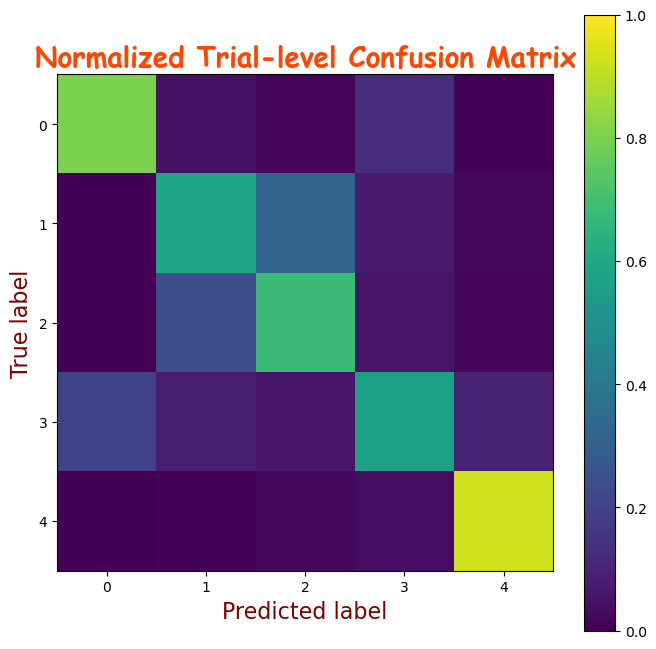

In [31]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(8, 8))
plt.imshow(cm_norm, interpolation="nearest", vmin=0, vmax=1)
plt.colorbar()
plt.xlabel("Predicted label", fontdict = functions.normalFont)
plt.ylabel("True label", fontdict = functions.normalFont)
plt.title("Normalized Trial-level Confusion Matrix", fontdict = functions.titleFont)
plt.show()

In [17]:
joblib.dump(model, "histgb_model.joblib")
joblib.dump(scaler, "scaler.joblib")

['scaler.joblib']